In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Entorno listo para JARVIS")

Entorno listo para JARVIS


# Proyecto de Minería de Datos – Grupo JARVIS_SANGRON

## Predicción del Riesgo de Deserción Estudiantil en Educación Superior

**Metodología:** CRISP-DM  
**Fase:** Comprensión del Negocio y Comprensión de los Datos  
**Dataset principal:** Open University Learning Analytics Dataset (OULAD)

**Integrantes:** Carla Valeria Encinas Cano-
                Victor Asturizaga Plata-
                Joel Herrera Pericon-
                Joel Eduardo Condoreno Chura-
                Vicente Oscar Claros Mamani

## Objetivo de negocio

El proyecto busca identificar patrones asociados al abandono estudiantil en educación superior utilizando el dataset OULAD.

El análisis pretende reconocer características académicas y contextuales relacionadas con un mayor riesgo de abandono, con el fin de apoyar futuras decisiones de seguimiento e intervención académica.

La decisión que se busca apoyar es la identificación de grupos de estudiantes con mayor riesgo de abandono para priorizar acciones preventivas.

## 1. Carga y descripción del dataset

In [2]:
url = "https://raw.githubusercontent.com/marloft/MachineLearning/refs/heads/master/Documents/ML/PhD/Datasets/Open%20University%20Learning%20Analytics%20Dataset%20-%20OULAD/studentInfo.csv"

df = pd.read_csv(url)

df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [3]:
print("Número de registros:", df.shape[0])
print("Número de variables:", df.shape[1])

print("\nColumnas del dataset:")
print(df.columns.tolist())

Número de registros: 32593
Número de variables: 12

Columnas del dataset:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              31482 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result          32593 non-null  str  
dtypes: int64(3), str(9)
memory usage: 3.0 MB


### Ficha técnica del dataset

- **Registros:** 32.593
- **Variables originales:** 12
- **Unidad de análisis:** inscripción estudiante–módulo–presentación.
- **Variables numéricas de análisis:** `num_of_prev_attempts`, `studied_credits`.
- **Identificador:** `id_student`.
- **Variables categóricas:** `code_module`, `code_presentation`, `gender`, `region`,
  `highest_education`, `imd_band`, `age_band`, `disability`, `final_result`.
- **Variable objetivo derivada:** `abandono`.

## 2. Definición de la variable objetivo

In [5]:
df["abandono"] = (df["final_result"] == "Withdrawn").astype(int)

df[["final_result", "abandono"]].head(10)

,final_result,abandono
0,Pass,0
1,Pass,0
2,Withdrawn,1
3,Pass,0
4,Pass,0
5,Pass,0
6,Pass,0
7,Pass,0
8,Pass,0
9,Pass,0


### Definición del target

La variable objetivo `abandono` se deriva de `final_result`:

- `abandono = 1`: `Withdrawn`.
- `abandono = 0`: `Pass`, `Fail` o `Distinction`.

`final_result` se utiliza únicamente para construir la etiqueta y deberá excluirse
como predictor durante el modelado para evitar fuga de información. `id_student`
tampoco será utilizado como predictor.

In [6]:
print(df["abandono"].value_counts())

abandono
0    22437
1    10156
Name: count, dtype: int64


In [7]:
print(df["abandono"].value_counts(normalize=True) * 100)

abandono
0    68.839935
1    31.160065
Name: proportion, dtype: float64


## 3. Calidad de los datos

In [8]:
print(df.isnull().sum())

code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
abandono                   0
dtype: int64


In [9]:
# Resumen de valores faltantes
faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0]

print("=== VARIABLES CON DATOS FALTANTES ===")

if len(faltantes) == 0:
    print("No existen valores faltantes.")
else:
    for variable, cantidad in faltantes.items():
        porcentaje = cantidad / len(df) * 100
        print(f"{variable}: {cantidad} registros ({porcentaje:.2f}%)")

=== VARIABLES CON DATOS FALTANTES ===
imd_band: 1111 registros (3.41%)


In [10]:
duplicados = df.duplicated().sum()
estudiantes_unicos = df["id_student"].nunique()

print("Registros duplicados exactos:", duplicados)
print("Total de registros:", len(df))
print("Estudiantes únicos:", estudiantes_unicos)

Registros duplicados exactos: 0
Total de registros: 32593
Estudiantes únicos: 28785


### Interpretación de la calidad de los datos

Se realizó una revisión de valores faltantes y registros duplicados antes de continuar con el análisis exploratorio.

La variable `imd_band` presenta valores faltantes. Durante esta fase de EDA estos registros se conservarán, ya que eliminarlos prematuramente podría ocasionar pérdida de información relevante.

El tratamiento definitivo de los valores faltantes será evaluado posteriormente durante la fase de preparación de datos de CRISP-DM.

Los registros duplicados exactos también fueron revisados para identificar posibles problemas de calidad antes del modelado.

In [11]:
faltantes_imd = df["imd_band"].isnull().sum()
porcentaje_imd = df["imd_band"].isnull().mean() * 100

print("Faltantes en imd_band:", faltantes_imd)
print(f"Porcentaje de faltantes: {porcentaje_imd:.2f}%")

Faltantes en imd_band: 1111
Porcentaje de faltantes: 3.41%


## 4. Cálculo del baseline y meta

### Métrica principal: Tasa de abandono estudiantil

La métrica principal del proyecto es la **tasa de abandono estudiantil**.

Esta métrica representa el porcentaje de inscripciones estudiante–módulo–presentación cuyo resultado final corresponde a `Withdrawn`.

**Unidad de medida:** porcentaje (%).

**Fórmula:**

$$
\text{Tasa de abandono} =
\frac{\text{Número de abandonos}}
{\text{Número total de registros}}
\times 100
$$

Esta métrica permite establecer una línea base del problema y posteriormente evaluar posibles mejoras.

In [12]:
total = len(df)
abandonos = df["abandono"].sum()
no_abandonos = total - abandonos
tasa_abandono = df["abandono"].mean()

print("=== BASELINE DE DESERCIÓN ===")
print("Total de registros:", total)
print("Abandonos:", abandonos)
print("No abandonos:", no_abandonos)
print(f"Tasa de abandono: {tasa_abandono:.2%}")

=== BASELINE DE DESERCIÓN ===
Total de registros: 32593
Abandonos: 10156
No abandonos: 22437
Tasa de abandono: 31.16%


In [13]:
reduccion_objetivo = 0.10
meta_abandono = tasa_abandono * (1 - reduccion_objetivo)

print(f"Baseline actual: {tasa_abandono:.2%}")
print(f"Reducción propuesta: {reduccion_objetivo:.0%}")
print(f"Meta de tasa de abandono: {meta_abandono:.2%}")

Baseline actual: 31.16%
Reducción propuesta: 10%
Meta de tasa de abandono: 28.04%


### Meta tentativa

Se propone, como escenario futuro, reducir la tasa de abandono en un 10 % respecto a la línea base.

Esta reducción representa una meta tentativa y no un resultado alcanzado. Su finalidad es establecer un punto de referencia para evaluar posteriormente la utilidad del análisis y de futuros modelos predictivos.

## 5. Análisis Exploratorio de Datos (EDA)

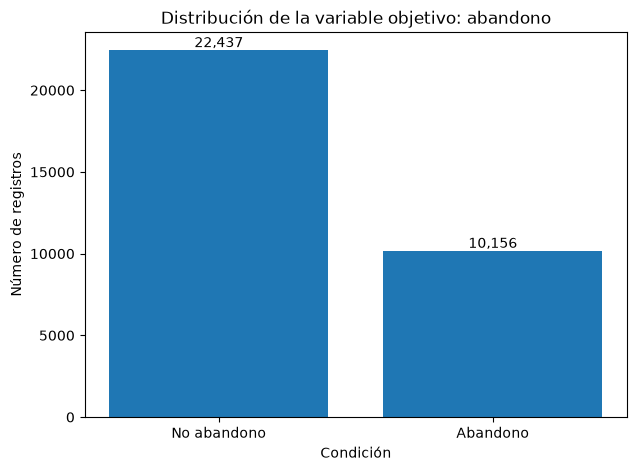

In [14]:
conteo_abandono = df["abandono"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

barras = plt.bar(
    ["No abandono", "Abandono"],
    [conteo_abandono[0], conteo_abandono[1]]
)

plt.title("Distribución de la variable objetivo: abandono")
plt.ylabel("Número de registros")
plt.xlabel("Condición")

for barra in barras:
    plt.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height() + 200,
        f"{int(barra.get_height()):,}",
        ha="center"
    )

plt.show()

### Interpretación de la variable objetivo

El dataset contiene 10.156 casos de abandono y 22.437 casos de no abandono. 
Esto representa una tasa histórica de abandono del 31,16 %, valor que se 
establece como línea base (baseline) del proyecto.

La distribución presenta un desbalance moderado entre ambas clases, por lo que 
en etapas posteriores será necesario considerar métricas de evaluación como 
Recall y F1-score, además de la exactitud.

In [15]:
abandono_modulo = (
    df.groupby("code_module")["abandono"]
      .mean()
      .sort_values(ascending=False) * 100
)

print(abandono_modulo.round(2))

code_module
CCC    44.54
DDD    35.87
FFF    30.96
BBB    30.19
EEE    24.61
AAA    16.84
GGG    11.52
Name: abandono, dtype: float64


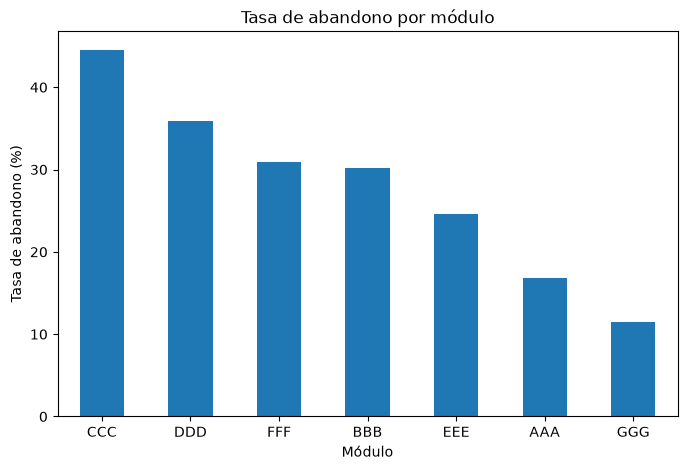

In [16]:
plt.figure(figsize=(8, 5))

abandono_modulo.plot(kind="bar")

plt.title("Tasa de abandono por módulo")
plt.xlabel("Módulo")
plt.ylabel("Tasa de abandono (%)")
plt.xticks(rotation=0)

plt.show()

### Interpretación del abandono por módulo

La tasa de abandono presenta diferencias importantes entre los módulos. Esto 
indica que el riesgo de abandono no es uniforme y que el módulo cursado puede 
estar relacionado con la probabilidad de retiro.

Por tanto, `code_module` constituye una variable relevante para continuar 
analizando durante las siguientes fases del proyecto.

In [17]:
df["studied_credits"].describe()

count    32593.000000
mean        79.758691
std         41.071900
min         30.000000
25%         60.000000
50%         60.000000
75%        120.000000
max        655.000000
Name: studied_credits, dtype: float64

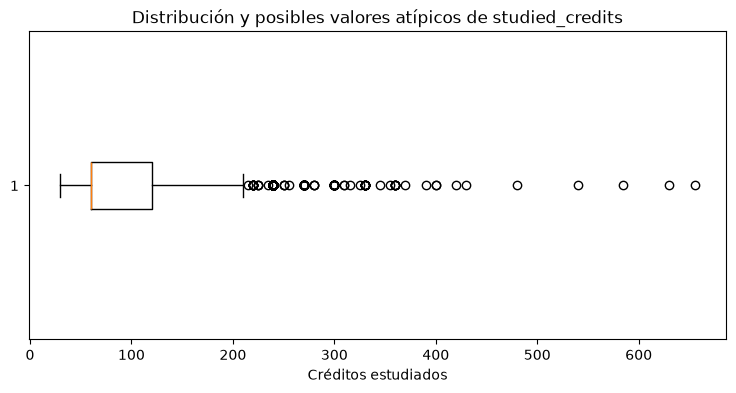

In [18]:
plt.figure(figsize=(9, 4))

plt.boxplot(df["studied_credits"], orientation="horizontal")

plt.title("Distribución y posibles valores atípicos de studied_credits")
plt.xlabel("Créditos estudiados")

plt.show()

### Análisis de posibles valores atípicos

La variable `studied_credits` presenta valores elevados respecto a la mayoría 
de los registros. Estos valores son considerados inicialmente como posibles 
outliers.

Sin embargo, durante el EDA no se eliminarán automáticamente, ya que primero 
debe determinarse si corresponden a errores de registro o a estudiantes con una 
carga académica excepcionalmente alta.

In [19]:
promedio_creditos = df.groupby("abandono")["studied_credits"].mean()

print("Promedio de créditos:")
print(promedio_creditos)

Promedio de créditos:
abandono
0    74.475643
1    91.430189
Name: studied_credits, dtype: float64


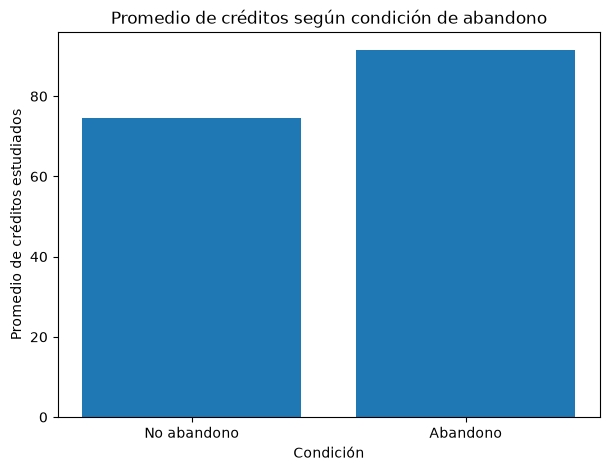

In [20]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["No abandono", "Abandono"],
    [promedio_creditos[0], promedio_creditos[1]]
)

plt.title("Promedio de créditos según condición de abandono")
plt.ylabel("Promedio de créditos estudiados")
plt.xlabel("Condición")

plt.show()

In [21]:
df["rango_creditos"] = pd.cut(
    df["studied_credits"],
    bins=[0, 60, 120, 180, float("inf")],
    labels=["Hasta 60", "61-120", "121-180", "Más de 180"]
)

abandono_creditos = (
    df.groupby("rango_creditos", observed=True)["abandono"]
      .mean() * 100
)

print(abandono_creditos.round(2))

rango_creditos
Hasta 60      25.35
61-120        38.75
121-180       47.93
Más de 180    61.92
Name: abandono, dtype: float64


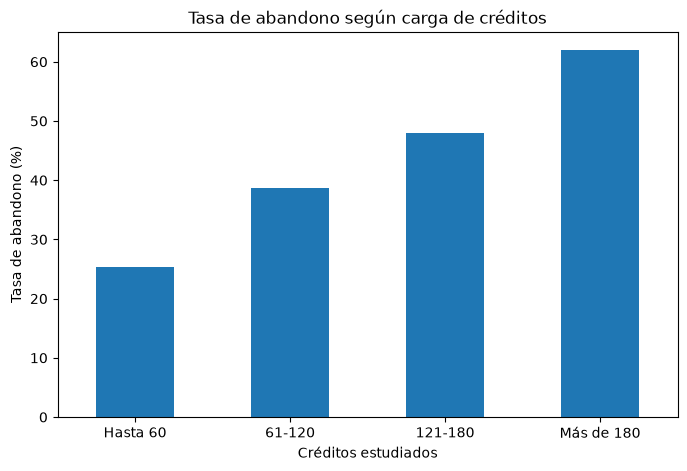

In [22]:
plt.figure(figsize=(8, 5))

abandono_creditos.plot(kind="bar")

plt.title("Tasa de abandono según carga de créditos")
plt.xlabel("Créditos estudiados")
plt.ylabel("Tasa de abandono (%)")
plt.xticks(rotation=0)

plt.show()

In [23]:
# Detección de posibles valores atípicos mediante el método IQR

Q1 = df["studied_credits"].quantile(0.25)
Q3 = df["studied_credits"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_creditos = df[
    (df["studied_credits"] < limite_inferior) |
    (df["studied_credits"] > limite_superior)
]

print("=== ANÁLISIS DE VALORES ATÍPICOS ===")
print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print("Posibles valores atípicos:", len(outliers_creditos))
print(f"Porcentaje: {len(outliers_creditos) / len(df) * 100:.2f}%")

=== ANÁLISIS DE VALORES ATÍPICOS ===
Q1: 60.00
Q3: 120.00
IQR: 60.00
Límite inferior: -30.00
Límite superior: 210.00
Posibles valores atípicos: 350
Porcentaje: 1.07%


In [24]:
# Resumen de la relación entre carga académica y abandono

print("=== TASA DE ABANDONO POR RANGO DE CRÉDITOS ===")
print(abandono_creditos.round(2))

rango_mayor = abandono_creditos.idxmax()
tasa_mayor = abandono_creditos.max()

rango_menor = abandono_creditos.idxmin()
tasa_menor = abandono_creditos.min()

print()
print(
    f"Mayor tasa de abandono: {rango_mayor} "
    f"({tasa_mayor:.2f}%)"
)

print(
    f"Menor tasa de abandono: {rango_menor} "
    f"({tasa_menor:.2f}%)"
)

print(
    f"Diferencia: {tasa_mayor - tasa_menor:.2f} puntos porcentuales"
)

=== TASA DE ABANDONO POR RANGO DE CRÉDITOS ===
rango_creditos
Hasta 60      25.35
61-120        38.75
121-180       47.93
Más de 180    61.92
Name: abandono, dtype: float64

Mayor tasa de abandono: Más de 180 (61.92%)
Menor tasa de abandono: Hasta 60 (25.35%)
Diferencia: 36.57 puntos porcentuales


### Relación entre carga académica y abandono

El análisis muestra que la tasa de abandono presenta diferencias entre los distintos rangos de créditos estudiados.

Esto sugiere que la carga académica puede estar relacionada con la probabilidad de abandono y constituye una variable relevante para continuar analizando.

Sin embargo, esta asociación es exploratoria y no permite afirmar que una mayor o menor carga de créditos sea la causa directa del abandono.

## 6. Hipótesis inicial

A partir del análisis exploratorio se plantea que características académicas 
como el módulo cursado y la carga de créditos pueden estar relacionadas con 
la probabilidad de abandono estudiantil.

La hipótesis preliminar es que determinados contextos académicos y mayores 
cargas de estudio presentan tasas de abandono diferentes respecto al resto 
de los estudiantes.

Estas relaciones son exploratorias y no implican causalidad. Su capacidad 
predictiva deberá comprobarse posteriormente durante las fases de preparación 
de datos, modelado y evaluación de CRISP-DM.

## 7. Hallazgo interesante

In [25]:
# Identificación del módulo con mayor y menor tasa de abandono

modulo_mayor = abandono_modulo.idxmax()
tasa_modulo_mayor = abandono_modulo.max()

modulo_menor = abandono_modulo.idxmin()
tasa_modulo_menor = abandono_modulo.min()

diferencia_modulos = tasa_modulo_mayor - tasa_modulo_menor

print("=== HALLAZGO INTERESANTE ===")
print(
    f"Módulo con mayor tasa de abandono: "
    f"{modulo_mayor} ({tasa_modulo_mayor:.2f}%)"
)

print(
    f"Módulo con menor tasa de abandono: "
    f"{modulo_menor} ({tasa_modulo_menor:.2f}%)"
)

print(
    f"Diferencia entre ambos: "
    f"{diferencia_modulos:.2f} puntos porcentuales"
)

=== HALLAZGO INTERESANTE ===
Módulo con mayor tasa de abandono: CCC (44.54%)
Módulo con menor tasa de abandono: GGG (11.52%)
Diferencia entre ambos: 33.02 puntos porcentuales


### Interpretación del hallazgo

Uno de los principales hallazgos del EDA es que el abandono estudiantil no se distribuye de manera uniforme entre los módulos.

Existen diferencias importantes en la tasa de abandono dependiendo del módulo cursado, lo que indica que el contexto académico puede estar relacionado con distintos niveles de riesgo.

Este hallazgo es relevante porque permite plantear que futuras estrategias de seguimiento no necesariamente deberían aplicarse de forma idéntica a todos los módulos.

La relación observada es exploratoria y no implica causalidad.

## 8. Conclusiones

El análisis exploratorio del dataset OULAD permitió establecer una tasa histórica de abandono del **31,16 %**, que constituye la línea base del proyecto.

Se identificaron diferencias en las tasas de abandono según el módulo cursado y la carga de créditos estudiados, por lo que estas variables presentan interés para las siguientes fases del proyecto.

También se detectaron valores faltantes y posibles valores atípicos que deberán ser tratados cuidadosamente durante la preparación de los datos.

Los resultados obtenidos corresponden a relaciones exploratorias y no permiten establecer causalidad.

En las siguientes fases de CRISP-DM se evaluará si estas y otras variables permiten construir modelos capaces de identificar estudiantes con mayor riesgo de abandono.